# Identify Patterns in Power Generation

This notebook analyzes solar power generation data from two plants to identify patterns, fluctuations, and correlations.

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style
plt.style.use('ggplot')
sns.set_palette('viridis')

## Loading and Preprocessing Data

In [16]:
# Load datasets
p1_path = '../../data/Plant_1_Generation_Data (2).csv'
p2_path = '../../data/Plant_2_Generation_Data (2).csv'

p1 = pd.read_csv(p1_path)
p2 = pd.read_csv(p2_path)

# Convert DATE_TIME to datetime objects
# Plant 1 format: dd-mm-yyyy HH:MM
p1['DATE_TIME'] = pd.to_datetime(p1['DATE_TIME'], dayfirst=True)
# Plant 2 format: yyyy-mm-dd HH:MM:SS
p2['DATE_TIME'] = pd.to_datetime(p2['DATE_TIME'])

# Add Plant label
p1['PLANT'] = 'Plant_1'
p2['PLANT'] = 'Plant_2'

# Combine data for unified analysis
df = pd.concat([p1, p2])

df.head()

,DATE_TIME,PLANT_ID,SOURCE_KEY,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD,PLANT
0,2020-05-15,4135001,1BY6WEcLGh8j5v7,0.0,0.0,0.0,6259559.0,Plant_1
1,2020-05-15,4135001,1IF53ai7Xc0U56Y,0.0,0.0,0.0,6183645.0,Plant_1
2,2020-05-15,4135001,3PZuoBAID5Wc2HD,0.0,0.0,0.0,6987759.0,Plant_1
3,2020-05-15,4135001,7JYdWkrLSPkdwr4,0.0,0.0,0.0,7602960.0,Plant_1
4,2020-05-15,4135001,McdE0feGgRqW7Ca,0.0,0.0,0.0,7158964.0,Plant_1


### 1. Split Generation Data by Source Key

In [17]:
# Grouping data by Source Key
source_groups = df.groupby('SOURCE_KEY')

print(f"Total unique sources: {len(source_groups)}")

# Example: Accessing a specific source
example_key = list(source_groups.groups.keys())[0]
source_data_example = source_groups.get_group(example_key)
source_data_example.head()

Total unique sources: 44


,DATE_TIME,PLANT_ID,SOURCE_KEY,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD,PLANT
0,2020-05-15 00:00:00,4135001,1BY6WEcLGh8j5v7,0.0,0.0,0.0,6259559.0,Plant_1
21,2020-05-15 00:15:00,4135001,1BY6WEcLGh8j5v7,0.0,0.0,0.0,6259559.0,Plant_1
42,2020-05-15 00:30:00,4135001,1BY6WEcLGh8j5v7,0.0,0.0,0.0,6259559.0,Plant_1
63,2020-05-15 00:45:00,4135001,1BY6WEcLGh8j5v7,0.0,0.0,0.0,6259559.0,Plant_1
84,2020-05-15 01:00:00,4135001,1BY6WEcLGh8j5v7,0.0,0.0,0.0,6259559.0,Plant_1


### 2. What is the average hourly yield?

Note: We will analyze both `DC_POWER` and `AC_POWER`. `DC_POWER` represents the energy captured by the panels, while `AC_POWER` is the output after inverter conversion.

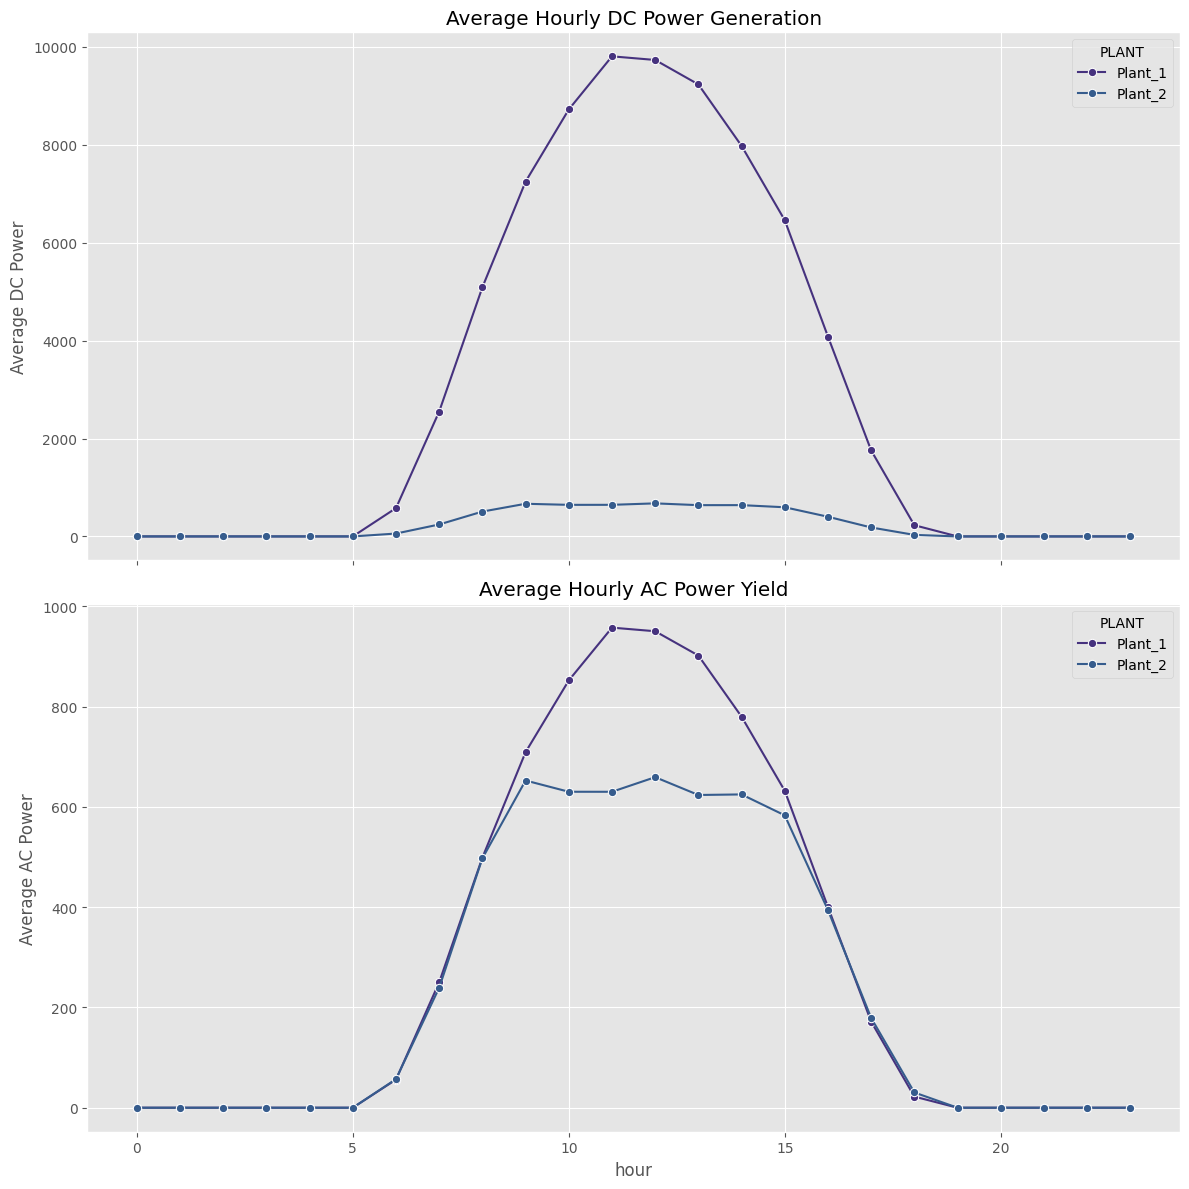

In [18]:
df['hour'] = df['DATE_TIME'].dt.hour

# Calculate average hourly DC and AC power
avg_hourly_yield = df.groupby(['PLANT', 'hour'])[['DC_POWER', 'AC_POWER']].mean().reset_index()

fig, axes = plt.subplots(2, 1, figsize=(12, 12), sharex=True)

# Plot DC Power
sns.lineplot(data=avg_hourly_yield, x='hour', y='DC_POWER', hue='PLANT', marker='o', ax=axes[0])
axes[0].set_title('Average Hourly DC Power Generation')
axes[0].set_ylabel('Average DC Power')

# Plot AC Power
sns.lineplot(data=avg_hourly_yield, x='hour', y='AC_POWER', hue='PLANT', marker='o', ax=axes[1])
axes[1].set_title('Average Hourly AC Power Yield')
axes[1].set_ylabel('Average AC Power')

plt.tight_layout()
plt.show()

### 3. What is the average daily yield?

In [19]:
df['date'] = df['DATE_TIME'].dt.date

# Daily yield is recorded as cumulative per day. The max value per day per source represents the total for that day.
daily_total_per_source = df.groupby(['PLANT', 'date', 'SOURCE_KEY'])['DAILY_YIELD'].max().reset_index()

avg_daily_yield = daily_total_per_source.groupby('PLANT')['DAILY_YIELD'].mean()
print("Average Daily Yield per Source:")
print(avg_daily_yield)

Average Daily Yield per Source:
PLANT
Plant_1    7193.581447
Plant_2    6256.376330
Name: DAILY_YIELD, dtype: float64


### 4. When is the daily yield fluctuating?

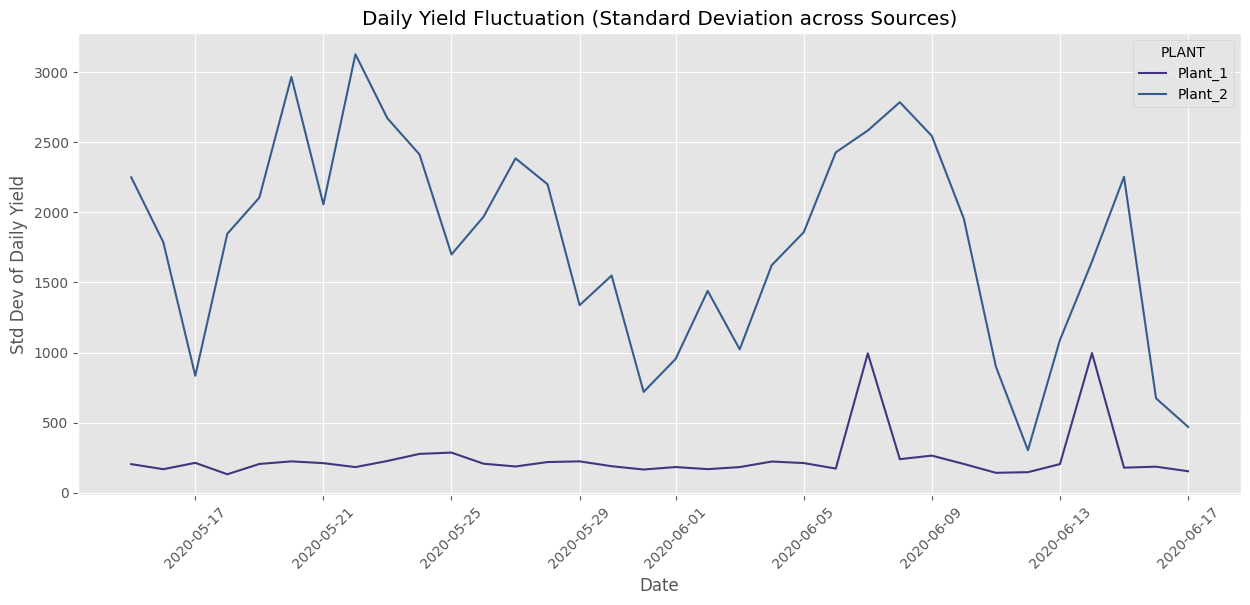

Highest fluctuations occur on dates with significantly different weather conditions or sensor issues.


In [20]:
# Calculating standard deviation of daily yield across all sources per day
daily_fluctuation = daily_total_per_source.groupby(['PLANT', 'date'])['DAILY_YIELD'].std().unstack(0)

plt.figure(figsize=(15, 6))
daily_fluctuation.plot(ax=plt.gca())
plt.title('Daily Yield Fluctuation (Standard Deviation across Sources)')
plt.ylabel('Std Dev of Daily Yield')
plt.xlabel('Date')
plt.xticks(rotation=45)
plt.show()

print("Highest fluctuations occur on dates with significantly different weather conditions or sensor issues.")

### 5. When is the hourly yield fluctuating?

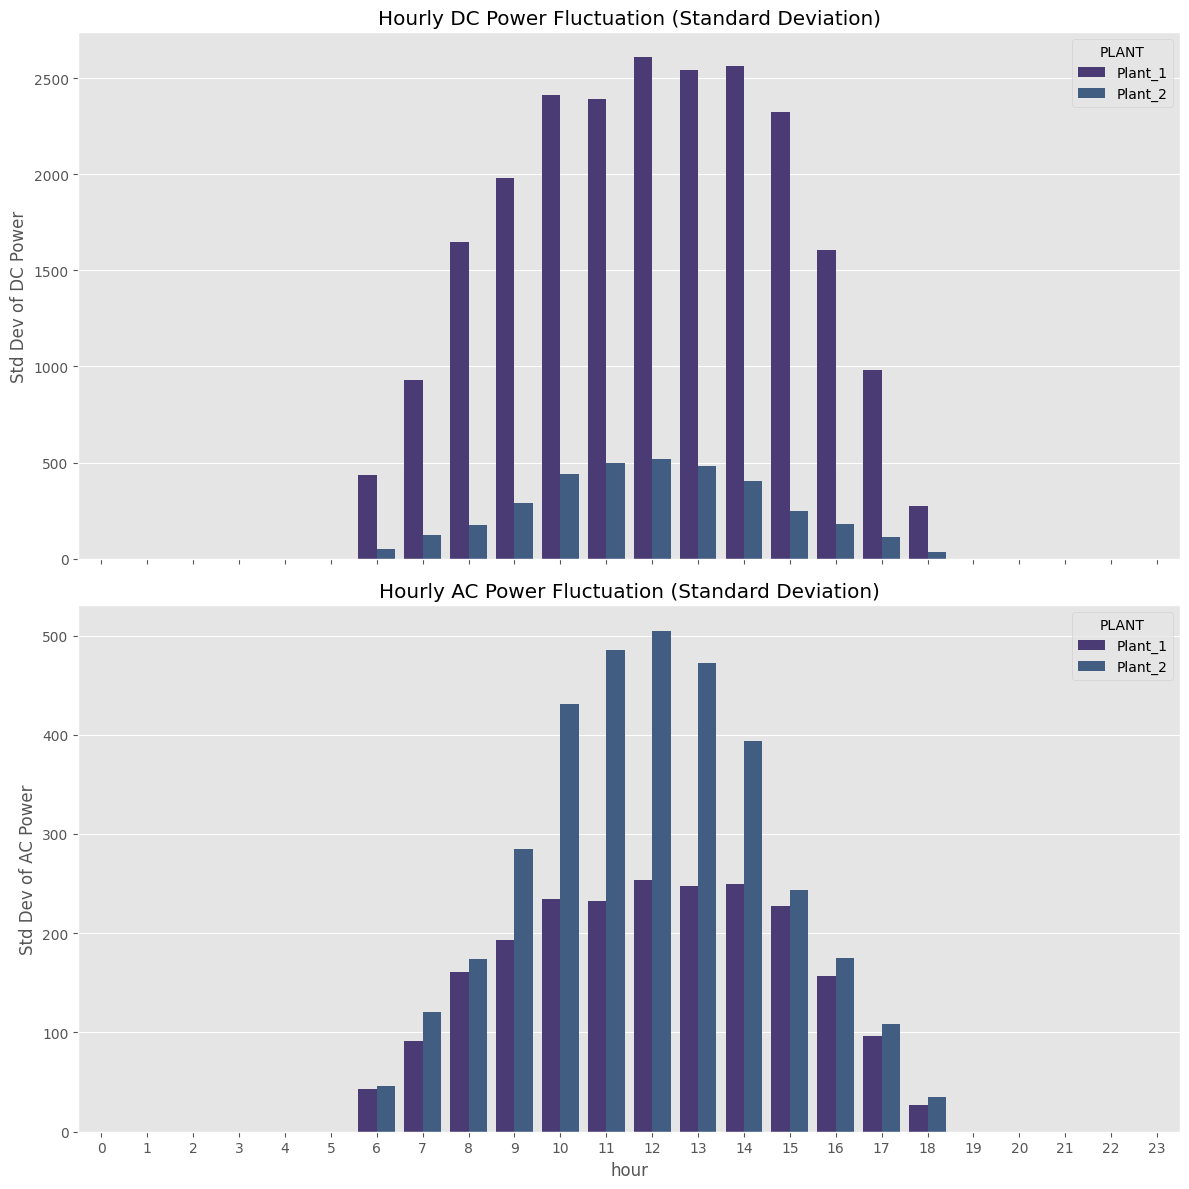

Fluctuations are highest during peak sun hours (10:00 - 15:00) due to cloud cover variability affecting both DC and AC output.


In [21]:
# Calculating standard deviation of DC and AC Power per hour
hourly_fluctuation = df.groupby(['PLANT', 'hour'])[['DC_POWER', 'AC_POWER']].std().reset_index()

fig, axes = plt.subplots(2, 1, figsize=(12, 12), sharex=True)

# DC Fluctuation
sns.barplot(data=hourly_fluctuation, x='hour', y='DC_POWER', hue='PLANT', ax=axes[0])
axes[0].set_title('Hourly DC Power Fluctuation (Standard Deviation)')
axes[0].set_ylabel('Std Dev of DC Power')

# AC Fluctuation
sns.barplot(data=hourly_fluctuation, x='hour', y='AC_POWER', hue='PLANT', ax=axes[1])
axes[1].set_title('Hourly AC Power Fluctuation (Standard Deviation)')
axes[1].set_ylabel('Std Dev of AC Power')

plt.tight_layout()
plt.show()

print("Fluctuations are highest during peak sun hours (10:00 - 15:00) due to cloud cover variability affecting both DC and AC output.")

### 6. How does datetime correlate with hourly yield?

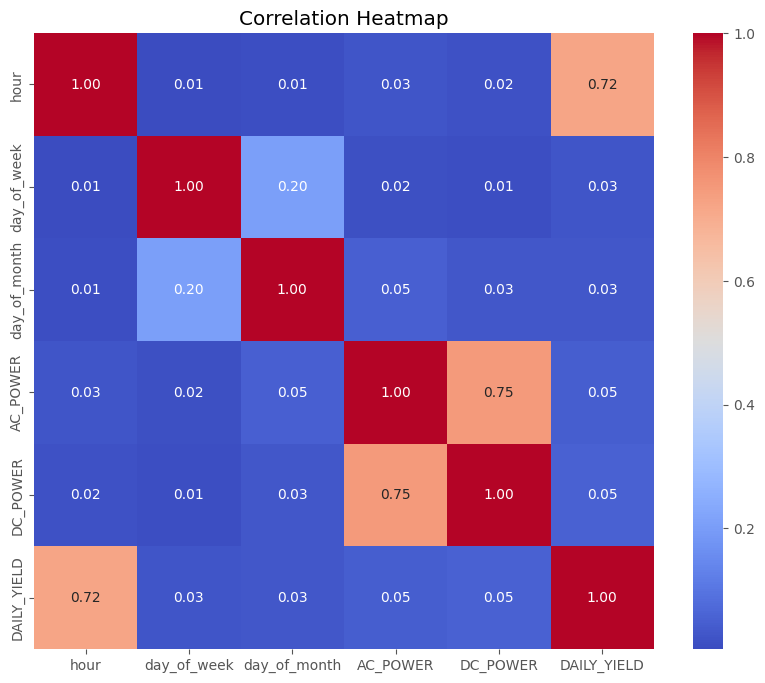

Observations:
- 'hour' has a non-linear but significant relationship with AC/DC Power.
- DC_POWER and AC_POWER are almost perfectly correlated (as expected).
- DAILY_YIELD correlates with 'hour' because it accumulates throughout the day.


In [22]:
# Feature engineering: extracting time features
df['day_of_week'] = df['DATE_TIME'].dt.dayofweek
df['day_of_month'] = df['DATE_TIME'].dt.day

corr_matrix = df[['hour', 'day_of_week', 'day_of_month', 'AC_POWER', 'DC_POWER', 'DAILY_YIELD']].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

print("Observations:")
print("- 'hour' has a non-linear but significant relationship with AC/DC Power.")
print("- DC_POWER and AC_POWER are almost perfectly correlated (as expected).")
print("- DAILY_YIELD correlates with 'hour' because it accumulates throughout the day.")